In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import warnings
warnings.filterwarnings("ignore")

In [2]:
df_churn = pd.read_csv('Churn_Modelling.csv')

**I. EDA**

Exited
0    7963
1    2037
Name: count, dtype: int64
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


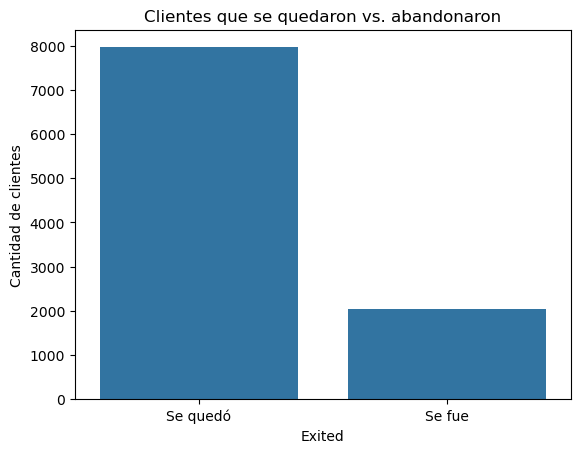

In [3]:
print(df_churn['Exited'].value_counts())
print(df_churn['Exited'].value_counts(normalize=True)*100)

#Veamoslo con un gráfico de barras
sns.countplot(data=df_churn, x='Exited')
plt.title('Clientes que se quedaron vs. abandonaron')
plt.xticks([0,1], ["Se quedó", "Se fue"])
plt.ylabel("Cantidad de clientes")
plt.show()

El porcentaje de abandonos es de un 20,37%. El porcentaje de clientes que permanecen es muy superior.

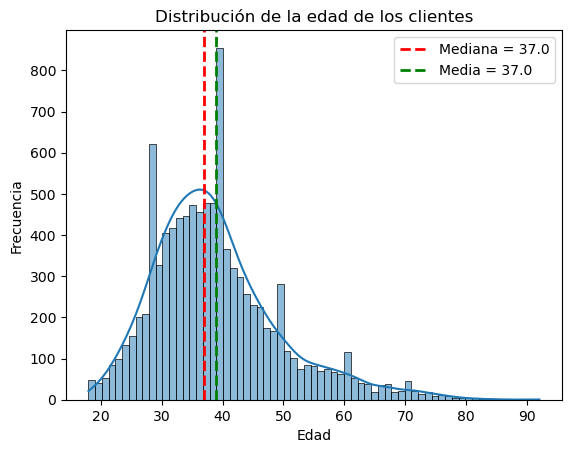

In [4]:
mediana_edad= df_churn['Age'].median()
media_edad=df_churn['Age'].mean()

sns.histplot(data=df_churn['Age'], kde=True)
plt.axvline(mediana_edad, color = 'red', linestyle= '--', linewidth=2, label=f'Mediana = {mediana_edad}')
plt.axvline(media_edad, color = 'green', linestyle= '--', linewidth=2, label=f'Media = {mediana_edad}')
plt.title("Distribución de la edad de los clientes")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

Situando la mediana de edad en los 37 años, vemos que está bastante desbalanceada la variable edad. Un gran número de adultos (28-40 años) y una larga cola hasta los 90. Destacan los dos mayores picos en los 27 y los 40 años.

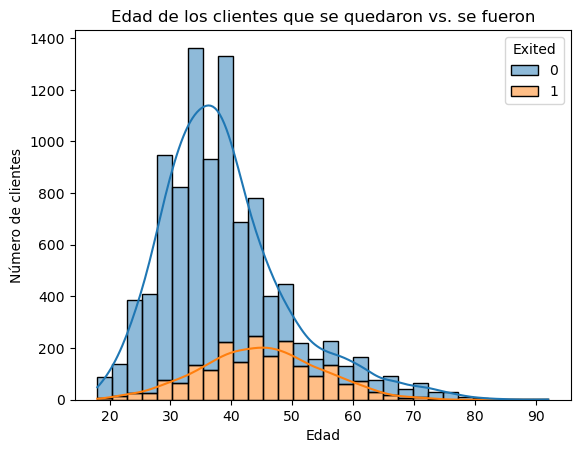

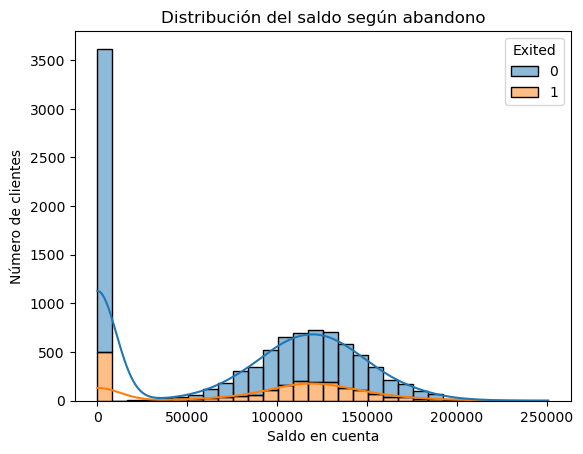

In [5]:
sns.histplot(data=df_churn, x='Age', hue='Exited', multiple='stack', bins=30, kde=True)
plt.title("Edad de los clientes que se quedaron vs. se fueron")
plt.xlabel("Edad")
plt.ylabel("Número de clientes")
plt.show()

sns.histplot(data=df_churn, x='Balance',hue='Exited', multiple='stack', bins=30, kde=True)
plt.title("Distribución del saldo según abandono")
plt.xlabel("Saldo en cuenta")
plt.ylabel("Número de clientes")
plt.show()

Primero, los clientes con mayor tasa de abandono se encuentran entre los 40 y 50 años, con una cola hasta los 70. Lo que nos indica que los clientes con mayor propensión al abandono son los adultos de >40 años.

Segundo, los clientes que más abandonan son aquellos con un saldo de 0, con un segundo pico entre los 100mil y 150mil.
Además de la edad, los clientes que más abandonan son aquellos con 0€, aunque también los que más permanecen, aquellos con entre 100mil y 150mil son los que más nos interesaría mantener por su buen balance.

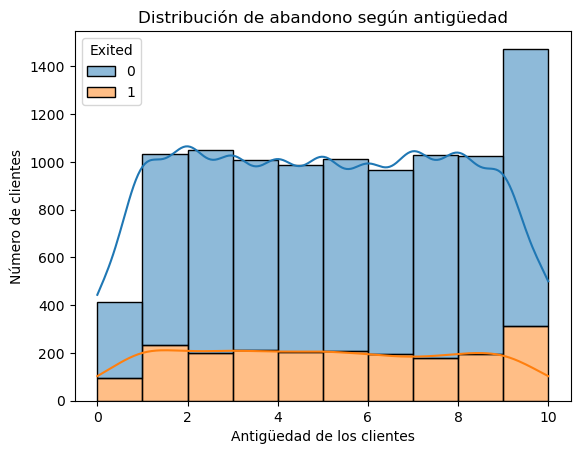

In [6]:
sns.histplot(data=df_churn, x='Tenure', hue='Exited', multiple='stack', bins=10, kde=True)
plt.title("Distribución de abandono según antigüedad")
plt.xlabel("Antigüedad de los clientes")
plt.ylabel("Número de clientes")
plt.show()

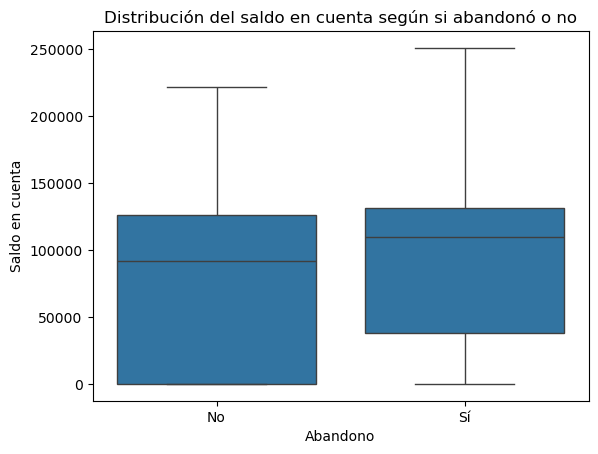

In [7]:
sns.boxplot(data=df_churn, x='Exited', y='Balance')
plt.title("Distribución del saldo en cuenta según si abandonó o no")
plt.xlabel("Abandono")
plt.ylabel("Saldo en cuenta")
plt.xticks([0,1], ["No", "Sí"])
plt.show()

Podemos ver que los clientes que han **SÍ** han abandonado el banco tenían **mayor** saldo en cuenta que aquellos que han permanecido.
Aunque la mediana no difiere mucho, también es superior en los que **SÍ** abandonan.
Además, muchas cuentas de clientes que permanecen están en 0, lo que podría significar inactividad.

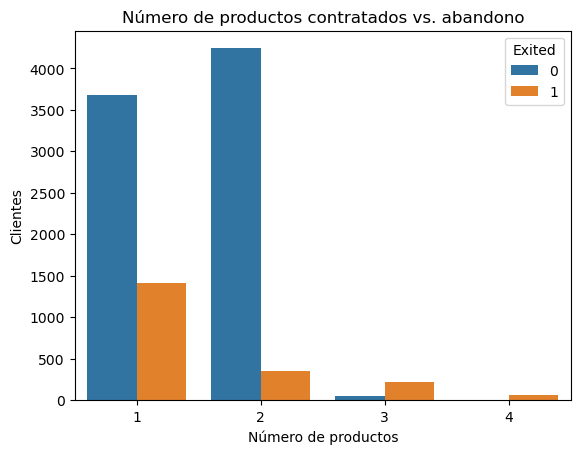

In [8]:
sns.countplot(data=df_churn, x='NumOfProducts', hue='Exited')
plt.title("Número de productos contratados vs. abandono")
plt.xlabel("Número de productos")
plt.ylabel("Clientes")
plt.show()

Clara tendencia a permanecer en el banco cuantos menos productos tienes contratados.
Es cierto que hay pocos clientes con más de 2 productos, pero su permanencia es casi nula. Los que más permanecen son aquellos con 1 o 2 productos contratados.

In [9]:
clientes_3_4_productos = df_churn[df_churn['NumOfProducts'].isin([3,4])]
print("Análisis de clientes con 3-4 productos:")
print(clientes_3_4_productos.groupby(['NumOfProducts', 'Exited']).agg({
    'Balance': ['count', 'mean', 'median'],
    'Age': 'mean',
    'IsActiveMember': 'mean',
    'Geography': lambda x: x.value_counts().index[0]
}).round(2))

Análisis de clientes con 3-4 productos:
                     Balance                         Age IsActiveMember  \
                       count      mean     median   mean           mean   
NumOfProducts Exited                                                      
3             0           46  25744.26       0.00  37.30           0.61   
              1          220  85853.09  106655.52  44.43           0.39   
4             1           60  93733.14  116808.20  45.68           0.48   

                     Geography  
                      <lambda>  
NumOfProducts Exited            
3             0         France  
              1        Germany  
4             1         France  


In [10]:
print(df_churn.groupby(['IsActiveMember', 'Exited']).agg({
    'Balance':'count',
}))

                       Balance
IsActiveMember Exited         
0              0          3547
               1          1302
1              0          4416
               1           735


**Clientes con 3 productos:**
46 permanecen vs 220 ser marchan. Los que se marchan tienen un promedio de saldo en cuenta mucho mayor que los que se quedan (~€26k / ~€86k), además la mediana de clientes que permanecen tienen cuentas INACTIVAS, y los que se van ~€107k. De aquellos que se marcharon solo el 39% eran clientes activos. Predomina Alemania como nacionalidad que abandona.

**Clientes con 4 productos:**
Todos se van. Tienen un alto saldo en cuenta y menos de la mitad (48%) eran activos. Predomina Francia como nacionalidad que abandona.
Estos clientes se encuentran en el rango de saldo y edad crítica. Como vimos en gráficos anteriores son los rangos más criticos en esos dos valores.

**CONCLUSIÓN:** Más productos + más dinero = MAYOR INSATISFACCIÓN

Clientes con más productos pero MENOS activos
Hipótesis: Productos "forzados" o mal vendidos



In [21]:
print(f"Clientes por país: {df_churn['Geography'].value_counts()}")
print("\nClientes por sexo:", df_churn['Gender'].value_counts())

Clientes por país: Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Clientes por sexo: Gender
Male      5457
Female    4543
Name: count, dtype: int64


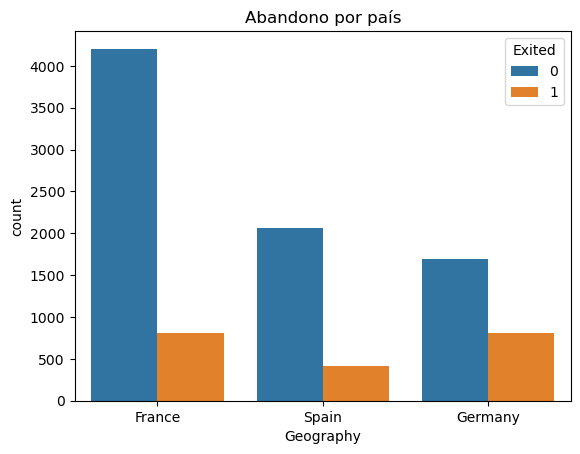

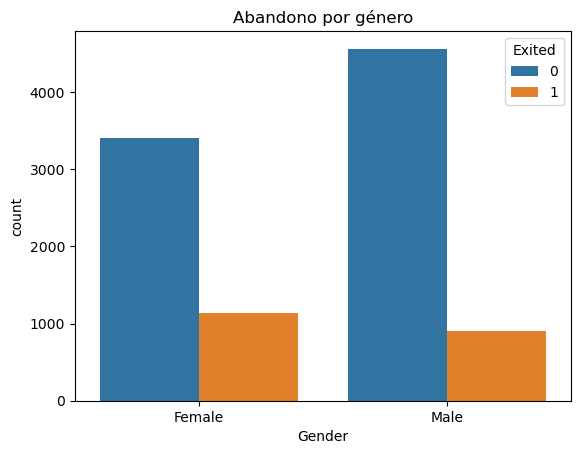

In [11]:
sns.countplot(data=df_churn, x='Geography', hue='Exited')
plt.title("Abandono por país")
plt.show()

sns.countplot(data=df_churn, x='Gender', hue='Exited')
plt.title("Abandono por género")
plt.show()

In [12]:
df_churned = df_churn[df_churn['Exited'] == 1].copy()

balance_lost_x_product = df_churned.groupby('NumOfProducts')['Balance'].sum()

print(balance_lost_x_product.apply(lambda x: f"€{x/1e6:.2f}M"))

NumOfProducts
1    €129.67M
2     €31.41M
3     €18.89M
4      €5.62M
Name: Balance, dtype: object


**II. FEATURE ENGINEERING**

In [13]:
alemania = df_churn[df_churn['Geography'] == 'Germany']
francia = df_churn[df_churn['Geography'] == 'France']
espana = df_churn[df_churn['Geography'] == 'Spain']

exited_alemania = alemania['Exited'].mean() * 100
exited_francia = francia['Exited'].mean() * 100
exited_espana = espana['Exited'].mean()*100
print("Abandono por países:\n")
print(f"% clientes abandono Alemania: {exited_alemania:.2f}%")
print(f"\n% clientes abandono Francia: {exited_francia:.2f}%")
print(f"\n% clientes abandono España: {exited_espana:.2f}%")

Abandono por países:

% clientes abandono Alemania: 32.44%

% clientes abandono Francia: 16.15%

% clientes abandono España: 16.67%


Los clientes Alemanes abandonan más, en proporción, que sus homólogos francesos y españoles. Y los más fieles son los franceses.
Las mujeres son las que más abandonan y representan un menor número de clientes.

In [14]:
#Clientes de alto valor y con valor 0

df_churn['HighValue']=(df_churn['Balance']>100000).astype(int)
df_churn['ZeroBalance']=(df_churn['Balance']==0).astype(int)

#Segmentos de edad estratégicos

df_churn['CriticalAge']=((df_churn['Age']>=40) & (df_churn['Age']<=50)).astype(int)
df_churn['YoungAdult']=((df_churn['Age']>=25) & (df_churn['Age']<=35)).astype(int)

#Clientes con alto 'Balance' y muchos 'NumOfProducts'
df_churn['HighValueMultiProduct']=((df_churn['Balance']>80000) & (df_churn['NumOfProducts']>=3)).astype(int)

#Identificamos los clientes que tienen varios productos pero en cuentas inactivas
df_churn['InactiveMultiProduct']=((df_churn['NumOfProducts']>=3) & (df_churn['IsActiveMember']==0)).astype(int)

#Factores que más determinan el CHURN
df_churn['PremiumAtRisk']=((df_churn['Balance']>=80000) & (df_churn['Age']>=40) & (df_churn['NumOfProducts']>=3)).astype(int)

#Segmentación de clientes por su valor
df_churn['CustomerValueRisk'] = np.select([
    (df_churn['NumOfProducts'] >= 3) & (df_churn['Balance'] > 80000),
    (df_churn['NumOfProducts'] == 2) & (df_churn['Balance'] > 50000),
    (df_churn['NumOfProducts'] == 1) & (df_churn['Balance'] > 0),
    (df_churn['Balance'] == 0)
], ['CRITICAL_RISK', 'HIGH_VALUE', 'GROWTH_POTENTIAL', 'INACTIVE'], 
default='STANDARD')

In [15]:
#Relacionamos el Balance del usuario con el número de productos(NumOfProducts)
df_churn['Balance_x_NumOfProducts'] = df_churn['Balance'] * df_churn['NumOfProducts']
#Veremos los clientes pasivos. Con tarjeta (HasCrCard) pero inactivo (IsActiveMemeber = 0)
df_churn['IsActive_x_HasCrCard'] = df_churn['IsActiveMember'] * df_churn['HasCrCard']
#Tasa adopción de productos. Número de productos (NumOfProducts) por el tiempo que lleva con nosotros (Tenure)
df_churn['ProductsPerTenure'] = df_churn['NumOfProducts'] / (df_churn['Tenure'] +1)
#Puntuación por lealtad(Ser activo, tener productos y años de permanencia)
df_churn['LoyaltyScore'] = df_churn['IsActiveMember'] + df_churn['HasCrCard'] + (df_churn['NumOfProducts'] > 1).astype(int) + df_churn['Tenure']
print(f"\nPuntos de lealtad: {df_churn['LoyaltyScore'].describe()}")
print(f"Valores de lealtad: {np.sort(df_churn['LoyaltyScore'].unique())}")


Puntos de lealtad: count    10000.000000
mean         6.725000
std          3.015972
min          0.000000
25%          4.000000
50%          7.000000
75%          9.000000
max         13.000000
Name: LoyaltyScore, dtype: float64
Valores de lealtad: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13]


Resalto la nueva variable de **Loyalty Score** que me resulta muy interesante y una manera muy sencilla y visual de saber ante que tipo de cliente nos encontramos de manera interdepartamentel. 0 es el valor mínimo y 13 el máximo, actualmente.


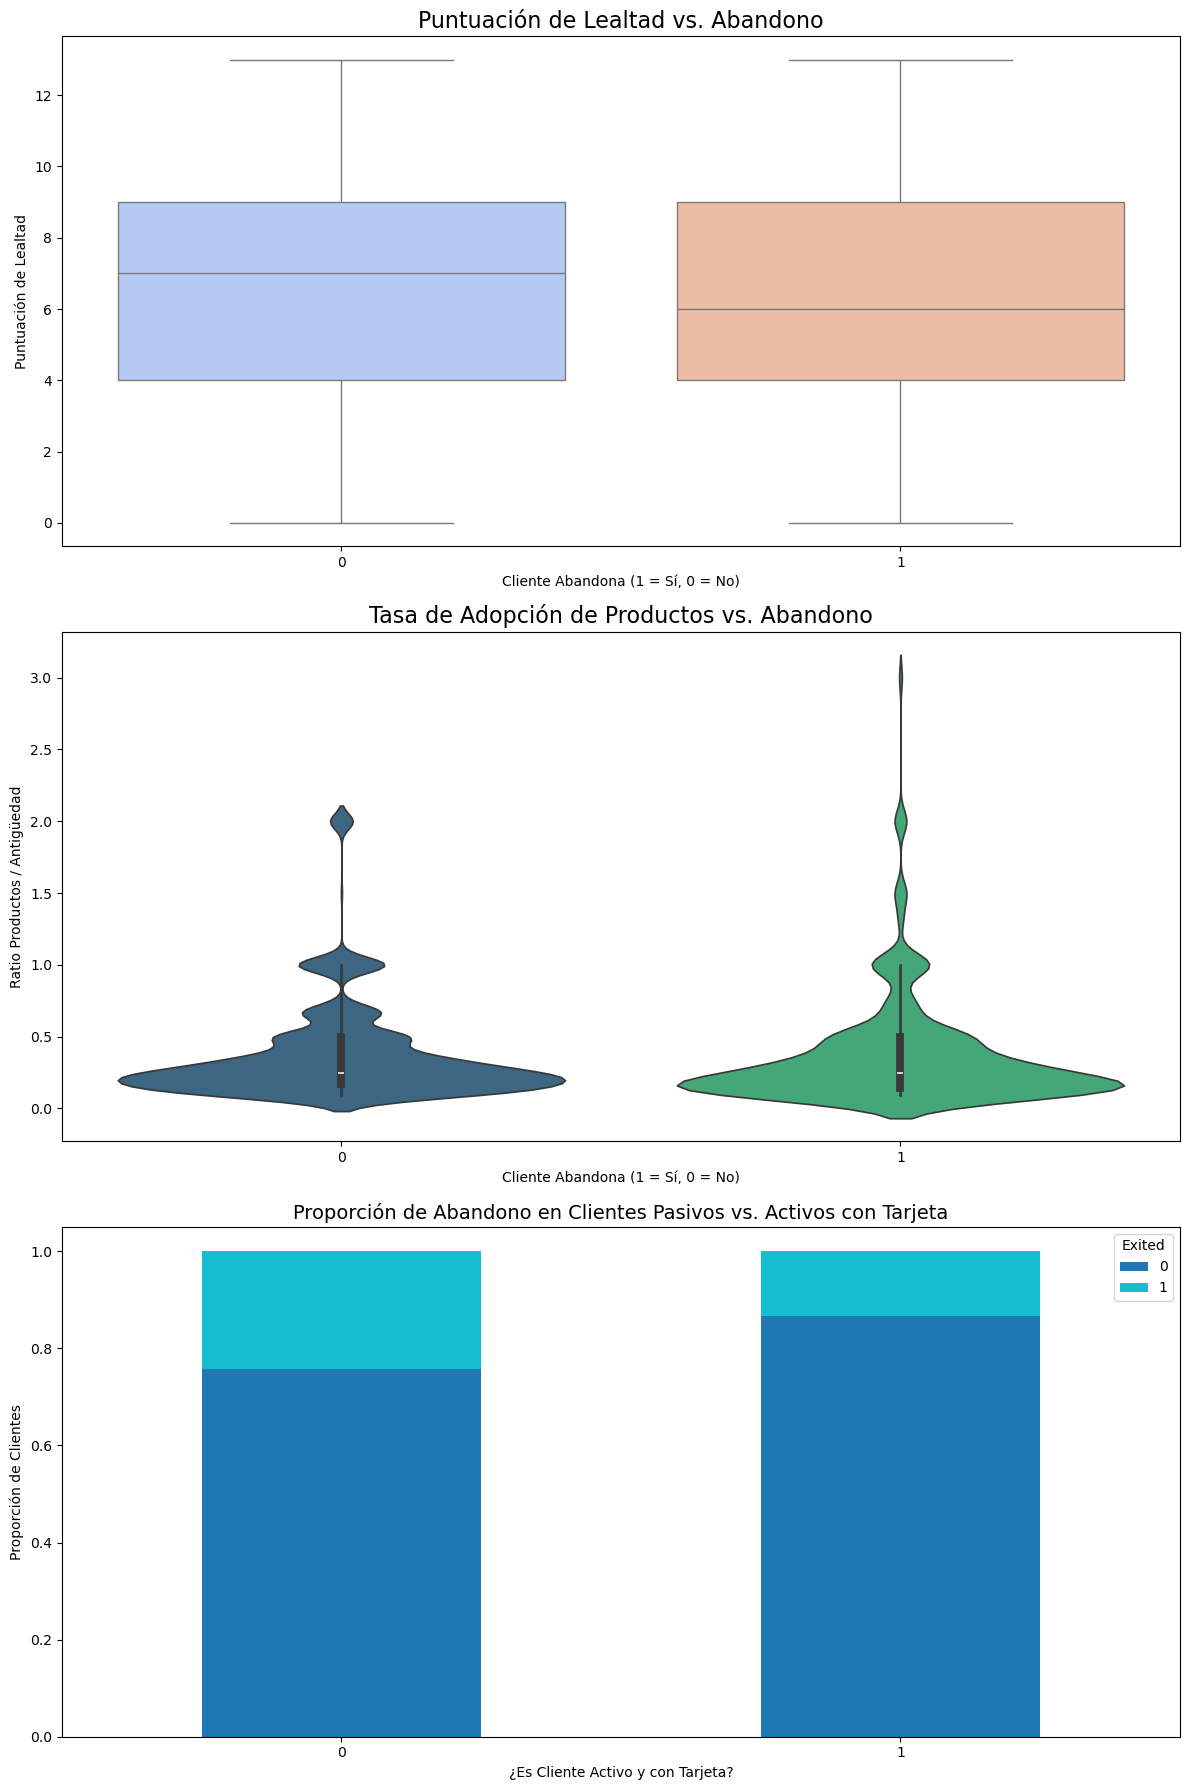

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# --- Gráfico 1: Boxplot ---
sns.boxplot(
    x='Exited', 
    y='LoyaltyScore', 
    data=df_churn, 
    palette='coolwarm', 
    ax=axes[0]
)
axes[0].set_title('Puntuación de Lealtad vs. Abandono', fontsize=16)
axes[0].set_xlabel('Cliente Abandona (1 = Sí, 0 = No)')
axes[0].set_ylabel('Puntuación de Lealtad')

# --- Gráfico 2: Violinplot ---
sns.violinplot(
    x='Exited', 
    y='ProductsPerTenure', 
    data=df_churn, 
    palette='viridis', 
    ax=axes[1]
)
axes[1].set_title('Tasa de Adopción de Productos vs. Abandono', fontsize=16)
axes[1].set_xlabel('Cliente Abandona (1 = Sí, 0 = No)')
axes[1].set_ylabel('Ratio Productos / Antigüedad')

# --- Gráfico 3: Barras ---
df_churn.groupby('IsActive_x_HasCrCard')['Exited'].value_counts(normalize=True).unstack().plot(
    kind='bar',
    stacked=True,
    colormap='tab10',
    ax=axes[2]
)
axes[2].set_title('Proporción de Abandono en Clientes Pasivos vs. Activos con Tarjeta', fontsize=14)
axes[2].set_xlabel('¿Es Cliente Activo y con Tarjeta?')
axes[2].set_ylabel('Proporción de Clientes')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


**Gráfico 1**: La diferencia no es grande, pero podemos ver como los clientes que SÍ churn tienen menor media en Loyalty, 6 puntos de Loyalty. Frente a los 7 puntos de Loyalty de la media de los que NO churn.

**Gráfico 2**: De nuevo, diferencias sutiles. Distribución muy similar, pero con diferentes características. Los clientes que han abandonado tienen una distribución más estirada. Volvemos a ver que mayor contratación se relaciona con mayor riesgo de churn.

**Gráfica 3**: Claramente, los que no son activos o no tienen tarjeta abandonan en mayor proporción.

In [17]:
df_churn.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'HighValue',
       'ZeroBalance', 'CriticalAge', 'YoungAdult', 'HighValueMultiProduct',
       'InactiveMultiProduct', 'PremiumAtRisk', 'CustomerValueRisk',
       'Balance_x_NumOfProducts', 'IsActive_x_HasCrCard', 'ProductsPerTenure',
       'LoyaltyScore'],
      dtype='object')

A continuación, eliminaremos las columnas 'RowNumber', 'CustomerId' y 'Surname' ya que no son columnas de utilidad para nuestro modelo.
Además, codificaremos la columna 'Gender' a una variable categórica binaria y usamos One-Hot Encogind con la variable 'Geography'.
En el caso de que Germany y Spain sean FALSE, deduciremos que se trata de France.

**III. MACHINE LEARNING**

In [18]:
df_ml=df_churn.copy()

df_ml=df_ml.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

df_ml['Gender']=df_ml['Gender'].map({'Male':0, 'Female':1})

df_ml = pd.get_dummies(df_ml, columns=['Geography'], drop_first=True)

In [19]:
#Los clientes senior y Alemanes son especialmente sensibles
df_ml['IsGermanSenior'] = ((df_ml['Geography_Germany'] == 1) & (df_ml['Age'] > 50)).astype(int)

In [20]:
!pip install scikit-learn
!pip install xgboost
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, accuracy_score, precision_score, f1_score, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

In [22]:
print(df_ml.head())

   CreditScore  Gender  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619       1   42       2       0.00              1          1   
1          608       1   41       1   83807.86              1          0   
2          502       1   42       8  159660.80              3          1   
3          699       1   39       1       0.00              2          0   
4          850       1   43       2  125510.82              1          1   

   IsActiveMember  EstimatedSalary  Exited  ...  InactiveMultiProduct  \
0               1        101348.88       1  ...                     0   
1               1        112542.58       0  ...                     0   
2               0        113931.57       1  ...                     1   
3               0         93826.63       0  ...                     0   
4               1         79084.10       0  ...                     0   

   PremiumAtRisk  CustomerValueRisk  Balance_x_NumOfProducts  \
0              0           INACTIVE     

In [23]:
risk_order = ['INACTIVE', 'STANDARD', 'GROWTH_POTENTIAL', 'HIGH_VALUE', 'CRITICAL_RISK']
df_ml['CustomerValueRisk_Encoded'] = df_ml['CustomerValueRisk'].map({
        'INACTIVE': 0,
        'STANDARD': 1, 
        'GROWTH_POTENTIAL': 2,
        'HIGH_VALUE': 3,
        'CRITICAL_RISK': 4
})
df_ml = df_ml.drop('CustomerValueRisk', axis=1)
print(df_ml.head())

   CreditScore  Gender  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619       1   42       2       0.00              1          1   
1          608       1   41       1   83807.86              1          0   
2          502       1   42       8  159660.80              3          1   
3          699       1   39       1       0.00              2          0   
4          850       1   43       2  125510.82              1          1   

   IsActiveMember  EstimatedSalary  Exited  ...  InactiveMultiProduct  \
0               1        101348.88       1  ...                     0   
1               1        112542.58       0  ...                     0   
2               0        113931.57       1  ...                     1   
3               0         93826.63       0  ...                     0   
4               1         79084.10       0  ...                     0   

   PremiumAtRisk  Balance_x_NumOfProducts  IsActive_x_HasCrCard  \
0              0                     

Escalamos las variables numéricas de nuestro dataset, no escalaremos aquellas que sean binarias.

Después separaremos las variables X, y (predictoras, objetivo)

In [31]:
scaler = StandardScaler()
cols_escalar = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
df_ml[cols_escalar] = scaler.fit_transform(df_ml[cols_escalar])

In [32]:
X = df_ml.drop(columns=['Exited'])
y = df_ml['Exited']

x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

print(f"Tamaño del conjunto de entrenamiento (x_train): {x_train.shape}")
print(f"\nTamaño del conjunto de prueba (x_test): {x_test.shape}")

Tamaño del conjunto de entrenamiento (x_train): (8000, 24)

Tamaño del conjunto de prueba (x_test): (2000, 24)


Vamos a crear y entrener diferentes modelos: LogisticRegression, RandomForest, DecisionTree, XGB y GradientBoosting

**IV. MODELOS**

In [33]:
modelos = {
    'log_reg': LogisticRegression(max_iter=1000),
    'Random Forest':RandomForestClassifier(random_state=42, n_estimators=100),
    'Decision Tree':DecisionTreeClassifier(random_state=42),
    'xgb':XGBClassifier(random_state=42, n_estimators=100, eval_metric='logloss'),
    'Gradient Boosting':GradientBoostingClassifier(random_state=42, n_estimators=100)
}

resultados= {}

for nombre,modelo in modelos.items():
    modelo.fit(x_train, y_train)
    
    #Predicciones
    y_pred=modelo.predict(x_test)
    y_prob= modelo.predict_proba(x_test)[:,1]
    
    #Métricas
    acc=accuracy_score(y_test, y_pred)
    prec=precision_score(y_test, y_pred)
    rec=recall_score(y_test, y_pred)
    f1=f1_score(y_test, y_pred)
    auc=roc_auc_score(y_test,y_prob)
    
    resultados[nombre]={
        'Accuracy':acc,
        'Precision':prec,
        'Recall':rec,
        'F1':f1,
        'AUC':auc
    }

    print(f"\nModelo: {nombre}")
    print(f"Accuracy: {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall: {rec:.3f}")
    print(f"F1-score: {f1:.3f}")
    print(f"AUC: {auc:.3f}")
    
    # Matriz de confusión
    print("""Matriz de confusión:""")
    print(confusion_matrix(y_test, y_pred))



Modelo: log_reg
Accuracy: 0.835
Precision: 0.677
Recall: 0.322
F1-score: 0.436
AUC: 0.815
Matriz de confusión:
[[1541   61]
 [ 270  128]]

Modelo: Random Forest
Accuracy: 0.856
Precision: 0.721
Recall: 0.447
F1-score: 0.552
AUC: 0.847
Matriz de confusión:
[[1533   69]
 [ 220  178]]

Modelo: Decision Tree
Accuracy: 0.789
Precision: 0.471
Recall: 0.490
F1-score: 0.480
AUC: 0.677
Matriz de confusión:
[[1383  219]
 [ 203  195]]

Modelo: xgb
Accuracy: 0.854
Precision: 0.684
Recall: 0.490
F1-score: 0.571
AUC: 0.831
Matriz de confusión:
[[1512   90]
 [ 203  195]]

Modelo: Gradient Boosting
Accuracy: 0.859
Precision: 0.734
Recall: 0.457
F1-score: 0.563
AUC: 0.859
Matriz de confusión:
[[1536   66]
 [ 216  182]]


Nos quedaremos con el modelo **Gradient Boosting** ya que tiene un bien equilibrio en 'Accuracy', 'Precision', un 'Recall' de los más altos, buen 'F1' y 'AUC'.
Predice muy bien los Verdaderos Negativos frente los falsos negativos (1536/66) y hay un buen equilibrio, respesto de otros modelos, entre falsos positivos y verdaderos positivos (216/182)

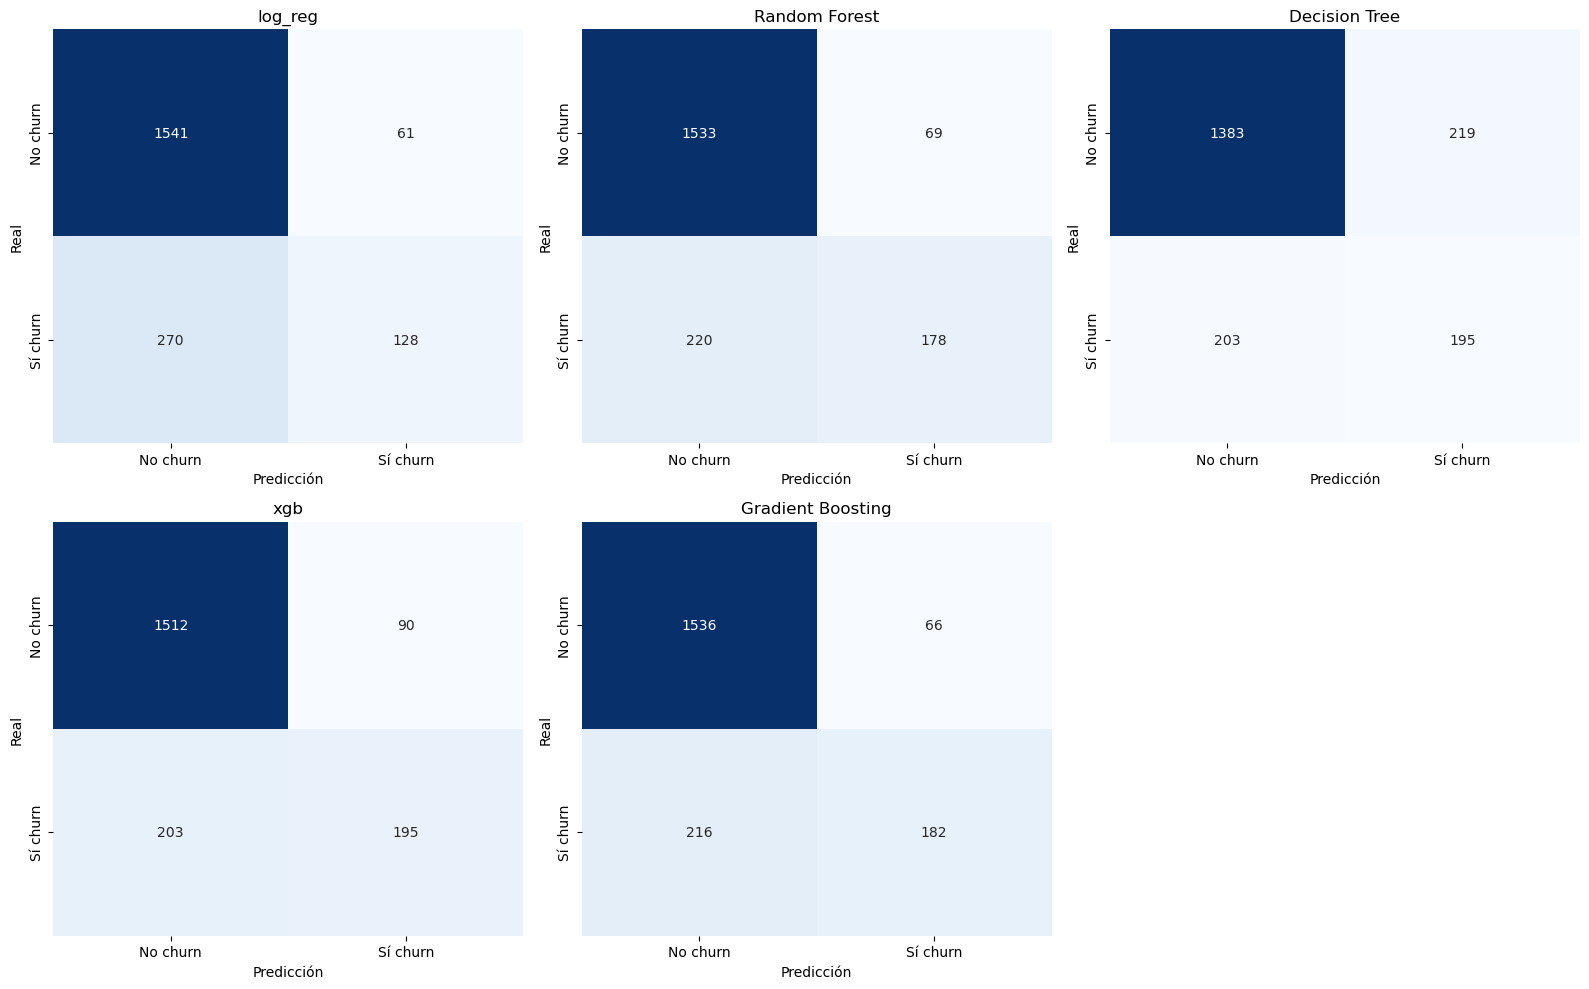

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, (nombre, modelo) in zip(axes.flat, modelos.items()):
    y_pred = modelo.predict(x_test)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["No churn", "Sí churn"],
                yticklabels=["No churn", "Sí churn"],
                ax=ax)
    ax.set_title(nombre, fontsize=12)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")


for i in range(len(modelos), len(axes.flat)):
    fig.delaxes(axes.flat[i])

plt.tight_layout()
plt.show()


In [35]:
resultados = pd.DataFrame.from_dict(resultados, orient='index')

resultados = resultados.sort_values(by='AUC', ascending=False)

print("--- Tabla Comparativa de Modelos ---")
display(resultados.style.format('{:.3f}'))

--- Tabla Comparativa de Modelos ---


,Accuracy,Precision,Recall,F1,AUC
Gradient Boosting,0.859,0.734,0.457,0.563,0.859
Random Forest,0.856,0.721,0.447,0.552,0.847
xgb,0.854,0.684,0.490,0.571,0.831
log_reg,0.835,0.677,0.322,0.436,0.815
Decision Tree,0.789,0.471,0.490,0.480,0.677


**V. SHAP**

                     Variable  Importancia
2                         Age     0.360951
5               NumOfProducts     0.290863
7              IsActiveMember     0.104089
4                     Balance     0.052734
20          Geography_Germany     0.051225
16    Balance_x_NumOfProducts     0.033151
11                CriticalAge     0.026679
0                 CreditScore     0.021258
8             EstimatedSalary     0.014799
1                      Gender     0.011411
19               LoyaltyScore     0.008900
23  CustomerValueRisk_Encoded     0.005912
18          ProductsPerTenure     0.003735
10                ZeroBalance     0.003525
14       InactiveMultiProduct     0.003113
12                 YoungAdult     0.002800
9                   HighValue     0.002132
13      HighValueMultiProduct     0.001472
17       IsActive_x_HasCrCard     0.000915
6                   HasCrCard     0.000146
15              PremiumAtRisk     0.000140
3                      Tenure     0.000051
21         

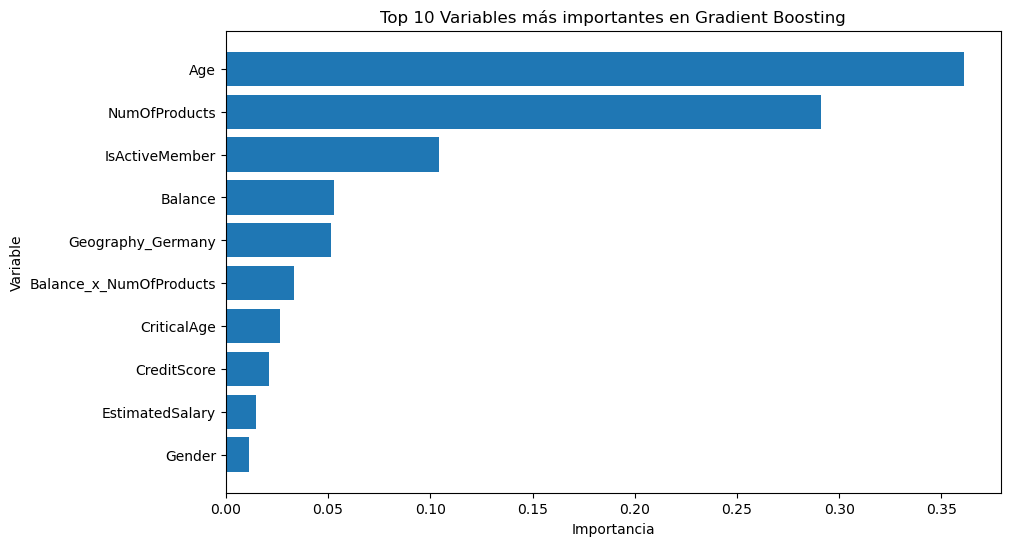

In [38]:
gb_final = GradientBoostingClassifier(random_state=42, n_estimators=100)
gb_final.fit(x_train, y_train)


importancias = gb_final.feature_importances_
features = x_train.columns


feat_importances = pd.DataFrame({
"Variable": features,
"Importancia": importancias
}).sort_values(by="Importancia", ascending=False)


print(feat_importances)


plt.figure(figsize=(10,6))
plt.barh(feat_importances["Variable"][:10], feat_importances["Importancia"][:10])
plt.gca().invert_yaxis() # Para que la más importante quede arriba
plt.title("Top 10 Variables más importantes en Gradient Boosting")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()


**VI. PREDICCIÓN**

In [64]:
## Seleccionar un cliente de prueba (ejemplo: el primero del test set)
ejemplo = x_test.iloc[[462]]
print("Datos del cliente seleccionado:")
print(ejemplo)

# Predicción
prediccion = gb_final.predict(ejemplo)[0]
probabilidad = gb_final.predict_proba(ejemplo)[0][1]
print("\nResultado de la predicción:")
print(">> El cliente ABANDONARÁ (Churn)" if prediccion == 1 else ">> El cliente NO abandonará")
print(f"Probabilidad estimada de churn: {probabilidad:.2f}")

Datos del cliente seleccionado:
      CreditScore  Gender       Age    Tenure   Balance  NumOfProducts  \
4950      -0.2331       1  0.579578  0.341352 -0.365714      -0.911583   

      HasCrCard  IsActiveMember  EstimatedSalary  HighValue  ...  \
4950          1               0         0.259665          0  ...   

      InactiveMultiProduct  PremiumAtRisk  Balance_x_NumOfProducts  \
4950                     0              0                 53667.44   

      IsActive_x_HasCrCard  ProductsPerTenure  LoyaltyScore  \
4950                     0           0.142857             7   

      Geography_Germany  Geography_Spain  IsGermanSenior  \
4950               True            False               0   

      CustomerValueRisk_Encoded  
4950                          2  

[1 rows x 24 columns]

Resultado de la predicción:
>> El cliente ABANDONARÁ (Churn)
Probabilidad estimada de churn: 0.67


**VII. CHI CUADRADO**

In [24]:
from scipy.stats import chi2_contingency

def chi_square_test(df_ml, col, target='Exited'):
    tabla = pd.crosstab(df_ml[col], df_ml[target])
    chi2, p, dof, expected = chi2_contingency(tabla)
    print(f"Variable: {col}")
    print("Tabla de contingencia:")
    print(tabla)
    print(f"Chi2: {chi2:.3f}, gl: {dof}, p-valor: {p:.5f}")
    if p < 0.05:
        print(" Existe asociación significativa con churn.\n")
    else:
        print("No hay asociación significativa con churn.\n")

# Aplica a variables categóricas clave
categorical_vars = ['Gender', 'HasCrCard', 'IsActiveMember', 'NumOfProducts', 'Age', 'Geography_Germany','LoyaltyScore', 'Tenure', ]

for col in categorical_vars:
    chi_square_test(df_ml, col)

Variable: Gender
Tabla de contingencia:
Exited     0     1
Gender            
0       4559   898
1       3404  1139
Chi2: 112.919, gl: 1, p-valor: 0.00000
 Existe asociación significativa con churn.

Variable: HasCrCard
Tabla de contingencia:
Exited        0     1
HasCrCard            
0          2332   613
1          5631  1424
Chi2: 0.471, gl: 1, p-valor: 0.49237
No hay asociación significativa con churn.

Variable: IsActiveMember
Tabla de contingencia:
Exited             0     1
IsActiveMember            
0               3547  1302
1               4416   735
Chi2: 242.985, gl: 1, p-valor: 0.00000
 Existe asociación significativa con churn.

Variable: NumOfProducts
Tabla de contingencia:
Exited            0     1
NumOfProducts            
1              3675  1409
2              4242   348
3                46   220
4                 0    60
Chi2: 1503.629, gl: 3, p-valor: 0.00000
 Existe asociación significativa con churn.

Variable: Age
Tabla de contingencia:
Exited   0   1
Age     